In [7]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# from google.colab import drive
# drive.mount("/content/drive")


In [9]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import date

In [10]:
DATA_DIRECTORY = Path("C:/Users/Milad/Documents/Git_Repo/epidote_project/data")

# Exploratory Data Analysis

In [11]:
# Load the cleaned data
df = pd.read_csv(DATA_DIRECTORY / "cleaned_data_second_version_2.csv")

In [12]:
# quick overview
print("columns:\n", df.columns.tolist())
print("datatypes:\n", df.dtypes)
print("Basis stats:\n", df.describe())

columns:
 ['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'Is Fraud?', 'Current Age', 'Retirement Age', 'Birth Year', 'Birth Month', 'Gender', 'Address', 'Apartment', 'City', 'State', 'Zipcode', 'Latitude', 'Longitude', 'Per Capita Income - Zipcode', 'Yearly Income - Person', 'Total Debt', 'FICO Score', 'Num Credit Cards', 'Card Brand', 'Card Type', 'Card Number', 'Expires', 'CVV', 'Has Chip', 'Cards Issued', 'Credit Limit', 'Acct Open Date', 'Year PIN last Changed', 'Card on Dark Web', 'Transaction Hour']
datatypes:
 User                             int64
Card                             int64
Year                             int64
Month                            int64
Day                              int64
Time                            object
Amount                         float64
Use Chip                        object
Merchant Name                    int64
Merchant City            

## Quick Setup

In [13]:
# Convert 'Is Fraud?' to numeric for easier analysis
df["Is Fraud?"] = df["Is Fraud?"].map({"No": 0, "Yes": 1})

# Quick look
print("Shape:", df.shape)
print("Fraud Count:", df["Is Fraud?"].value_counts())

Shape: (7374879, 44)
Fraud Count: Is Fraud?
0    7365651
1       9228
Name: count, dtype: int64


In [14]:
df["time_str"] = df["Time"].astype(str).str.zfill(4)

# Combine into a datetime string format "YYYY-MM-DD HH:MM"
df["datetime_str"] = (
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str).str.zfill(2)
    + "-"
    + df["Day"].astype(str).str.zfill(2)
    + " "
    + df["time_str"]
)
df["timestamp"] = pd.to_datetime(df["datetime_str"], format="%Y-%m-%d %H:%M")

# Drop intermediate columns
df.drop(["time_str", "datetime_str"], axis=1, inplace=True)

## Fraud Distribution

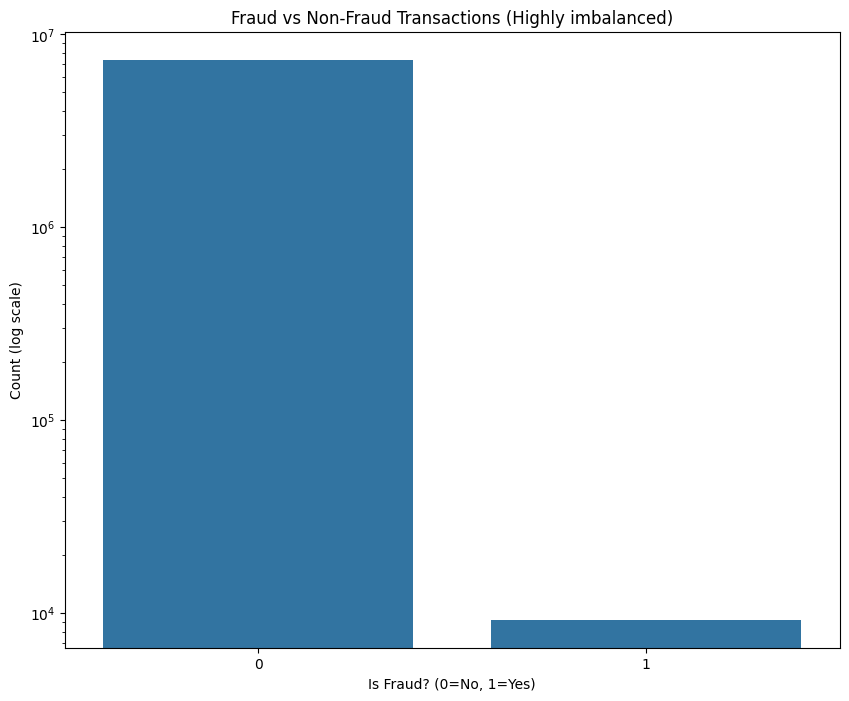

Fraud percentage is: 0.13%


In [15]:
# visualize the imbalance
plt.figure(figsize=(10, 8))
sns.countplot(x="Is Fraud?", data=df)
plt.xlabel("Is Fraud? (0=No, 1=Yes)")
plt.ylabel("Count (log scale)")
plt.title("Fraud vs Non-Fraud Transactions (Highly imbalanced)")
plt.yscale("log")  # Log scale to see the Fraud bar
plt.show()
print(f"Fraud percentage is: {df['Is Fraud?'].mean() * 100:.2f}%")

## Transaction Amount Analysis


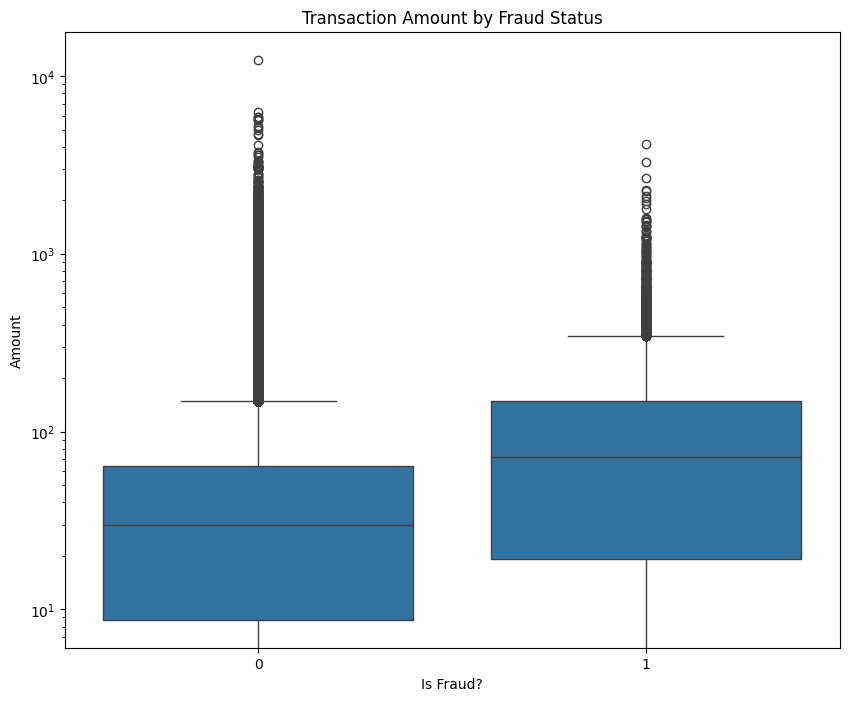

Amount stats by Fraud status:
               count        mean         std    min    25%     50%     75%  \
Is Fraud?                                                                    
0          7365651.0   42.943883   81.443264 -500.0   8.74  29.800   64.41   
1             9228.0  105.830920  183.700537 -500.0  19.14  71.695  149.56   

                max  
Is Fraud?            
0          12390.50  
1           4133.28  


In [16]:
plt.figure(figsize=(10, 8))
sns.boxplot(x=df["Is Fraud?"], y=df["Amount"], data=df)
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Is Fraud?")
plt.ylabel("Amount")
plt.yscale("log")
plt.show()

# stats for Fraud vs Non-fraud
print("Amount stats by Fraud status:")
print(df.groupby("Is Fraud?")["Amount"].describe())

The analysis indicates that fraudulent transactions tend to involve significantly higher amounts compared to non-fraudulent ones.

## Temporal Patterns

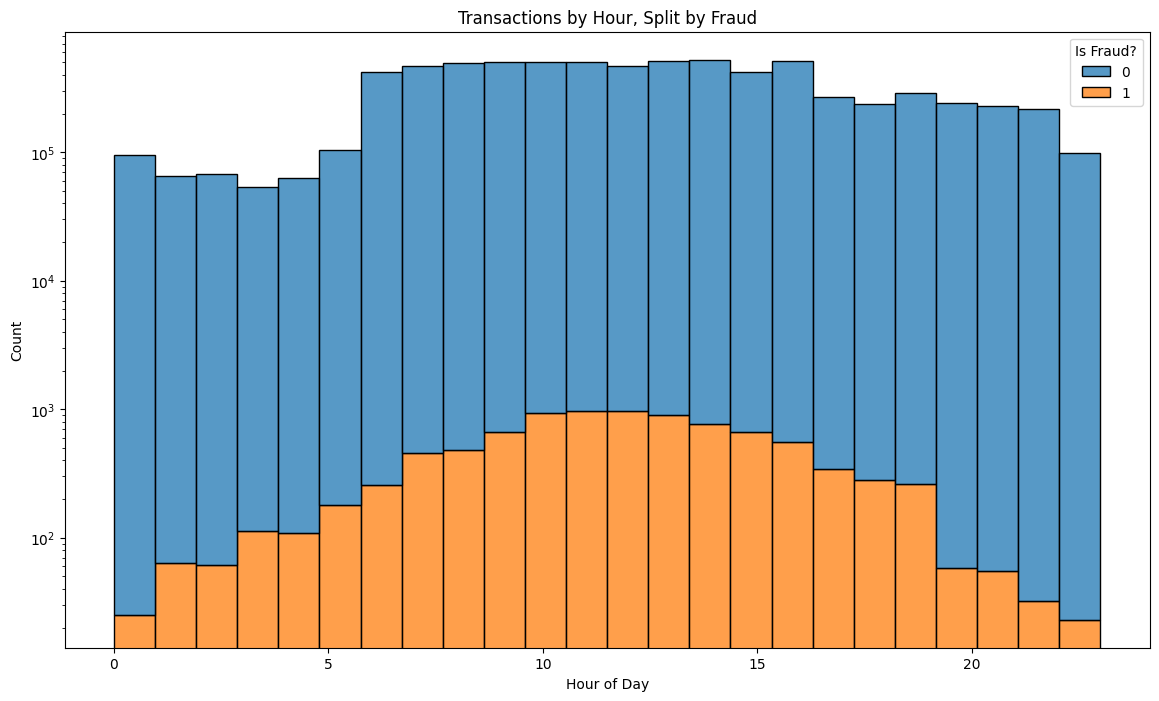

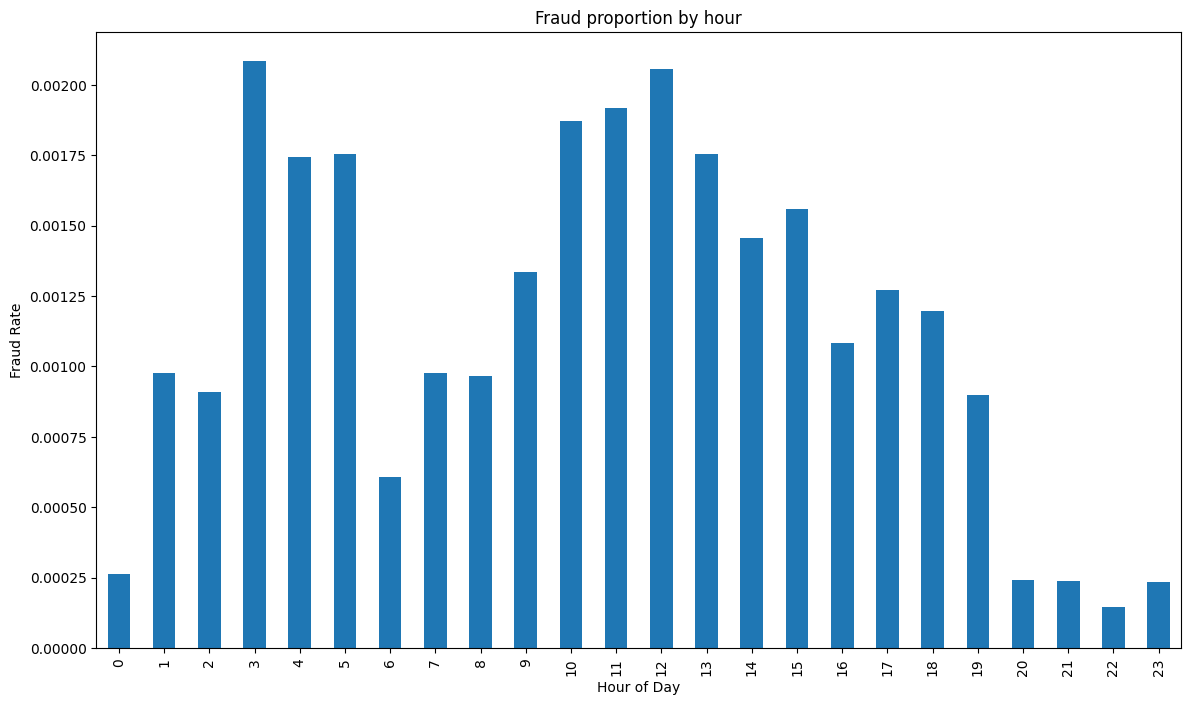

In [17]:
# Visualization of Transaction Distribution by Hour with Fraud vs Non-Fraud Comparison
plt.figure(figsize=(14, 8))
sns.histplot(x=df["Transaction Hour"], hue=df["Is Fraud?"], multiple="stack", bins=24)
plt.title("Transactions by Hour, Split by Fraud")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.yscale("log")  # Log scale to see fraud
plt.show()

# Fraud proportion by hour
hourly_fraud = df.groupby("Transaction Hour")["Is Fraud?"].mean()
plt.figure(figsize=(14, 8))
hourly_fraud.plot(kind="bar")
plt.title("Fraud proportion by hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

The early morning peak (3 AM - 5 AM) could indicate fraudsters are taking advantage of:

- Lower customer activity
- Reduced monitoring during non-business hours
- Automated fraud attacks during the night

The late morning to early afternoon peak (10 AM - 3 PM) may be related to:

- Social engineering attacks (e.g., phishing or scam calls)
- Fraud attempts blending in with normal business transaction volumes
- Exploiting working hours when victims may be distracted

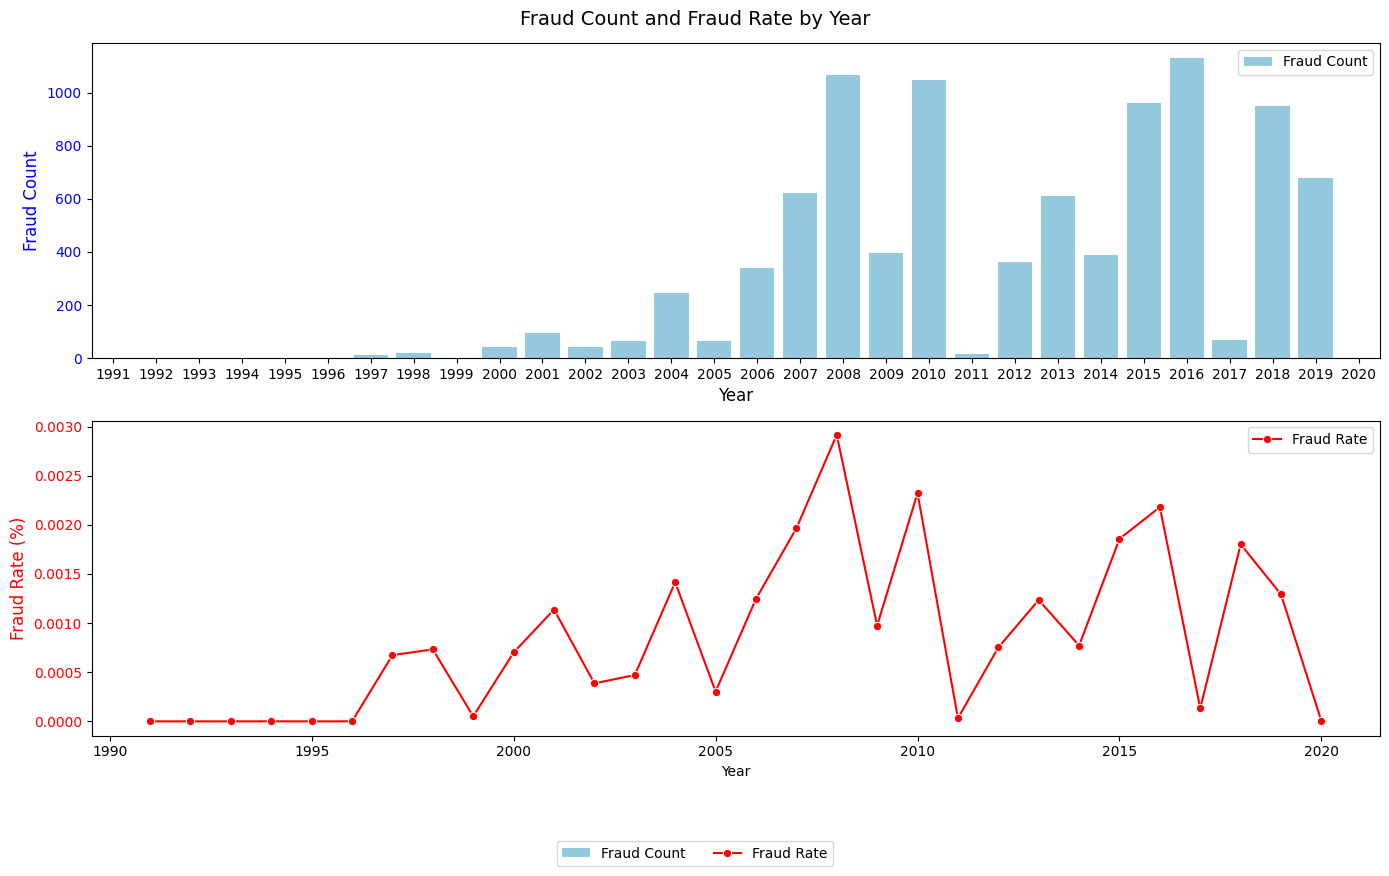

In [18]:
# year_based fraud analysis
year_fraud_data = df.groupby("Year").agg(
    total_count=("Is Fraud?", "count"),
    fraud_count=("Is Fraud?", "sum"),
    fraud_percentage=("Is Fraud?", "mean"),
)
year_fraud_data

# visualizing

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Bar plot for fraud count (left y-axis)
sns.barplot(
    x="Year",
    y="fraud_count",
    data=year_fraud_data,
    ax=axes[0],
    color="skyblue",
    label="Fraud Count",
)
axes[0].set_xlabel("Year", fontsize=12)
axes[0].set_ylabel("Fraud Count", fontsize=12, color="blue")
axes[0].tick_params(axis="y", labelcolor="blue")

# Line plot for fraud rate
sns.lineplot(
    x="Year",
    y="fraud_percentage",
    data=year_fraud_data,
    ax=axes[1],
    color="red",
    marker="o",
    label="Fraud Rate",
)
axes[1].set_ylabel("Fraud Rate (%)", fontsize=12, color="red")
axes[1].tick_params(axis="y", labelcolor="red")

# Titles and layout
fig.suptitle("Fraud Count and Fraud Rate by Year", fontsize=14)
fig.tight_layout()
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.show()

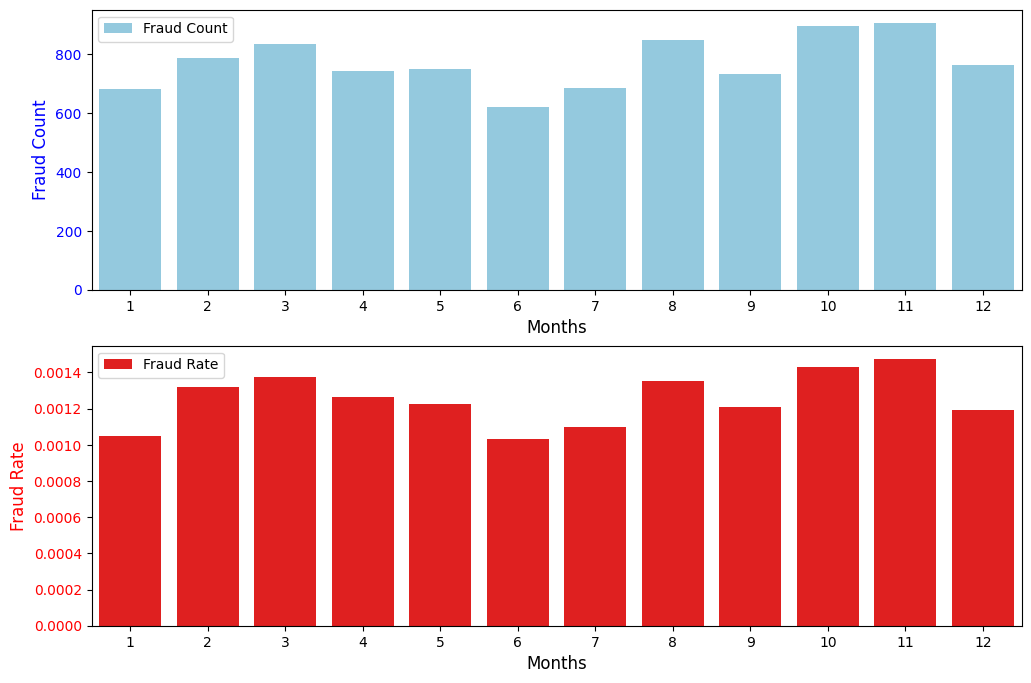

In [19]:
# month-based fraud analysis
month_fraud_data = (
    df.groupby("Month")
    .agg(
        total_count=("Is Fraud?", "count"),
        fraud_count=("Is Fraud?", "sum"),
        fraud_percentage=("Is Fraud?", "mean"),
    )
    .reset_index()
)
month_fraud_data
# fraud count by months
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
sns.barplot(
    x="Month",
    y="fraud_count",
    data=month_fraud_data,
    ax=axes[0],
    color="skyblue",
    label="Fraud Count",
)
axes[0].set_xlabel("Months", fontsize=12)
axes[0].set_ylabel("Fraud Count", fontsize=12, color="blue")
axes[0].tick_params(axis="y", labelcolor="blue")

# fraud rate by months
sns.barplot(
    x="Month",
    y="fraud_percentage",
    color="red",
    ax=axes[1],
    label="Fraud Rate",
    data=month_fraud_data,
)
axes[1].set_xlabel("Months", fontsize=12)
axes[1].set_ylabel("Fraud Rate", fontsize=12, color="red")
axes[1].tick_params(axis="y", labelcolor="red")

There is no significant variation in the fraud rate from month to month.

In [20]:
# Calculate fraud stats by day of the week
df["Date"] = pd.to_datetime(
    df[["Year", "Month", "Day"]].astype(str).agg("-".join, axis=1), errors="coerce"
)
df["Day_of_Week"] = df["Date"].dt.day_name()
day_fraud_data = df.groupby("Day_of_Week").agg(
    total_count=("Is Fraud?", "count"),
    fraud_count=("Is Fraud?", "sum"),
    fraud_percentage=("Is Fraud?", "mean"),
)
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
day_fraud_data = day_fraud_data.reindex(day_order)

In [21]:
day_fraud_data

,total_count,fraud_count,fraud_percentage
Day_of_Week,,,
Monday,1054308,1169,0.001109
Tuesday,1050447,1182,0.001125
Wednesday,1049435,958,0.000913
Thursday,1056653,1693,0.001602
Friday,1054154,1531,0.001452
Saturday,1057983,1171,0.001107
Sunday,1051899,1524,0.001449


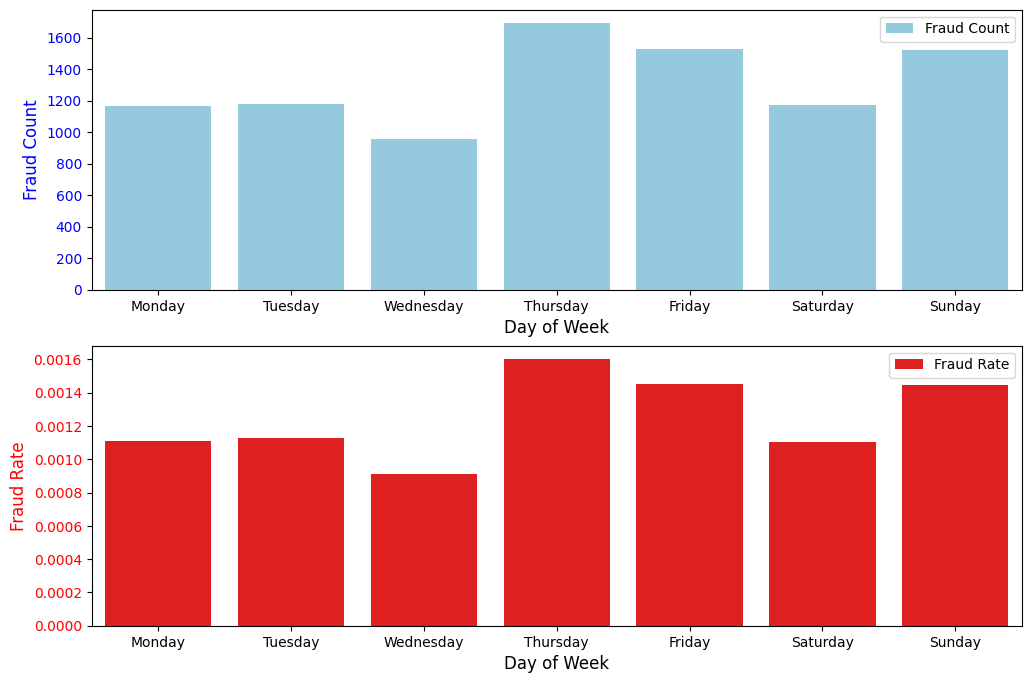

In [22]:
# fraud count by the day of week
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
sns.barplot(
    x="Day_of_Week",
    y="fraud_count",
    data=day_fraud_data,
    ax=axes[0],
    color="skyblue",
    label="Fraud Count",
)
axes[0].set_xlabel("Day of Week", fontsize=12)
axes[0].set_ylabel("Fraud Count", fontsize=12, color="blue")
axes[0].tick_params(axis="y", labelcolor="blue")

# fraud rate by the day of week
sns.barplot(
    x="Day_of_Week",
    y="fraud_percentage",
    color="red",
    ax=axes[1],
    label="Fraud Rate",
    data=day_fraud_data,
)
axes[1].set_xlabel("Day of Week", fontsize=12)
axes[1].set_ylabel("Fraud Rate", fontsize=12, color="red")
axes[1].tick_params(axis="y", labelcolor="red")

## Categorical Features

### Creating a New Feature: Transaction Type (CNP vs CP) Based on Merchant City

In [23]:
df["Transaction_type"] = df["Merchant City"].apply(
    lambda x: "CNP" if x == "ONLINE" else "CP"
)

In [24]:
# fraud rate by transaction type
df.groupby("Transaction_type")["Is Fraud?"].mean()

Transaction_type
CNP    0.006448
CP     0.000561
Name: Is Fraud?, dtype: float64

The analysis reveals that online transactions exhibit a higher fraud rate compared to offline transactions. This insight suggests that fraudsters may be more likely to target online transactions, possibly due to the reduced security measures associated with card-not-present (CNP) transactions

Feature engineered: a new feature, Transaction Type, was engineered based on the Merchant City column. Transactions labeled as "ONLINE" were categorized as CNP, and all others were categorized as CP.

### Feature: Has Chip

The Has Chip feature is specifically designed to strengthen the security of card-present (CP) transactions.

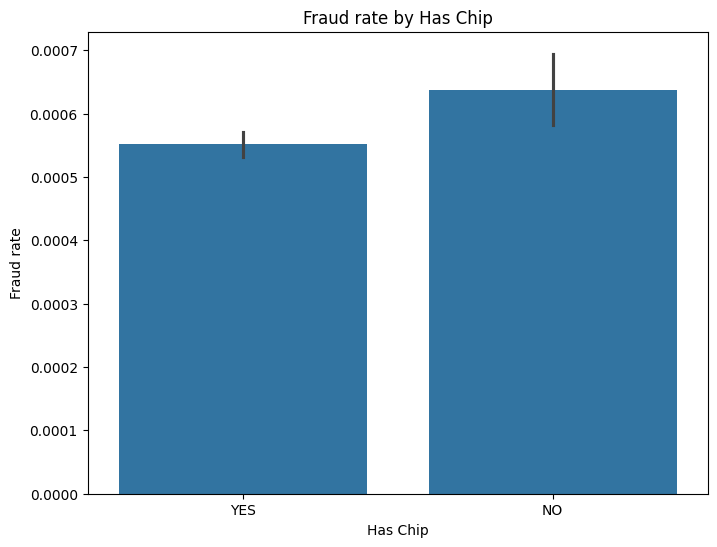

Has Chip
NO     0.000637
YES    0.000551
Name: Is Fraud?, dtype: float64

In [25]:
# Fraud rate by Has Chip
CP_transaction = df[df["Transaction_type"] == "CP"]
plt.figure(figsize=(8, 6))
sns.barplot(
    data=CP_transaction,
    x="Has Chip",
    y="Is Fraud?",
    estimator=lambda x: sum(x) / len(x),
)
plt.title("Fraud rate by Has Chip")
plt.xlabel("Has Chip")
plt.ylabel("Fraud rate")
plt.show()
CP_transaction.groupby("Has Chip")["Is Fraud?"].mean()

The analysis shows a higher fraud rate in card-present (CP) transactions for cards without a chip

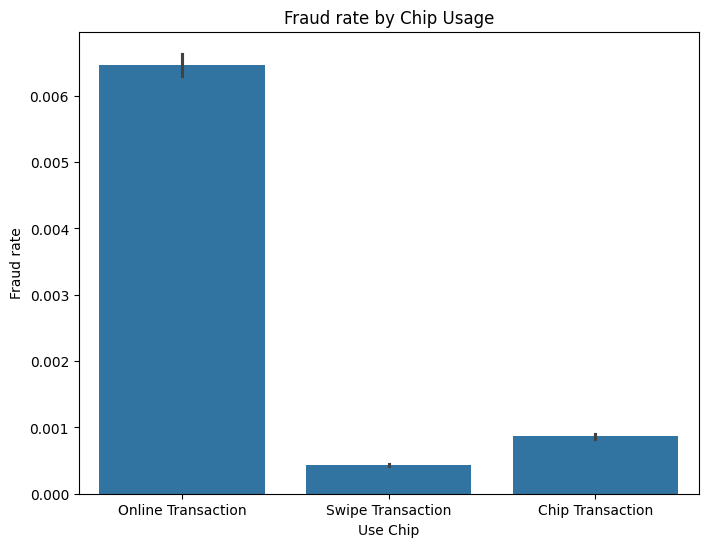

In [26]:
# Fraud rate by Use Chip
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="Use Chip", y="Is Fraud?", estimator=lambda x: sum(x) / len(x))
plt.title("Fraud rate by Chip Usage")
plt.ylabel("Fraud rate")
plt.show()

## Feature: Merchant state

Text(0, 0.5, 'Fraud Rate')

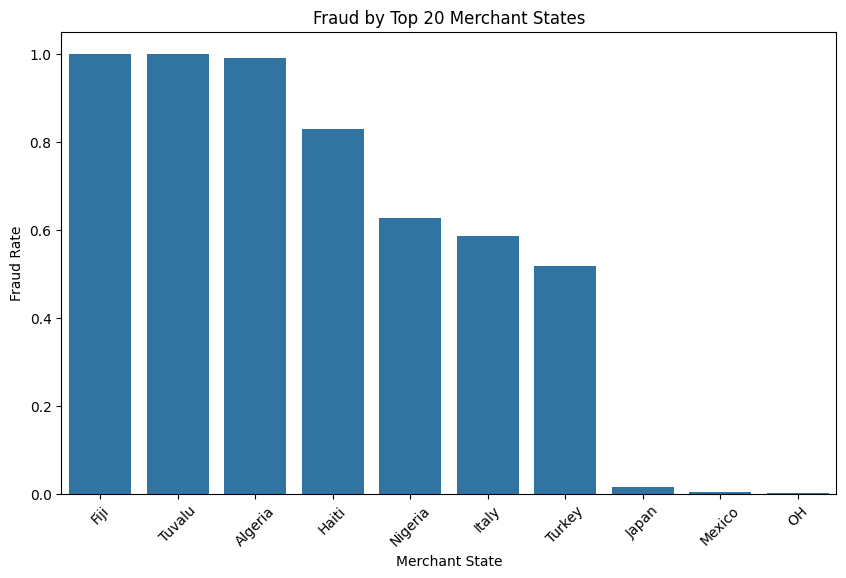

In [27]:
# Fraud rate by Merchant State based on high risk states (fraud rate of states > dataset fraud rate)
state_fraud_rate = CP_transaction.groupby("Merchant State")["Is Fraud?"].mean()
High_risk_state = state_fraud_rate[
    state_fraud_rate > df["Is Fraud?"].mean()
].sort_values(ascending=False)

# Select top 20 high-risk states
top_20_high_risk_states = High_risk_state.head(20)

# Plot fraud rate for high-risk states
plt.figure(figsize=(10, 6))
sns.barplot(x=top_20_high_risk_states.index, y=top_20_high_risk_states.values)
plt.title("Fraud by Top 20 Merchant States")
plt.xticks(rotation=45)
plt.xlabel("Merchant State")
plt.ylabel("Fraud Rate")

### Feature Engineered: High Risk State
This new feature flags states with a fraud rate higher than the overall fraud rate of the dataset.
States with a fraud rate greater than the overall rate are assigned a value of 1 (high risk),
while others are assigned a value of 0 (low risk).

In [28]:
high_risk_state_list = High_risk_state.index.tolist()
df["High_risk_state"] = df["Merchant State"].apply(
    lambda x: 1 if x in high_risk_state_list else 0
)

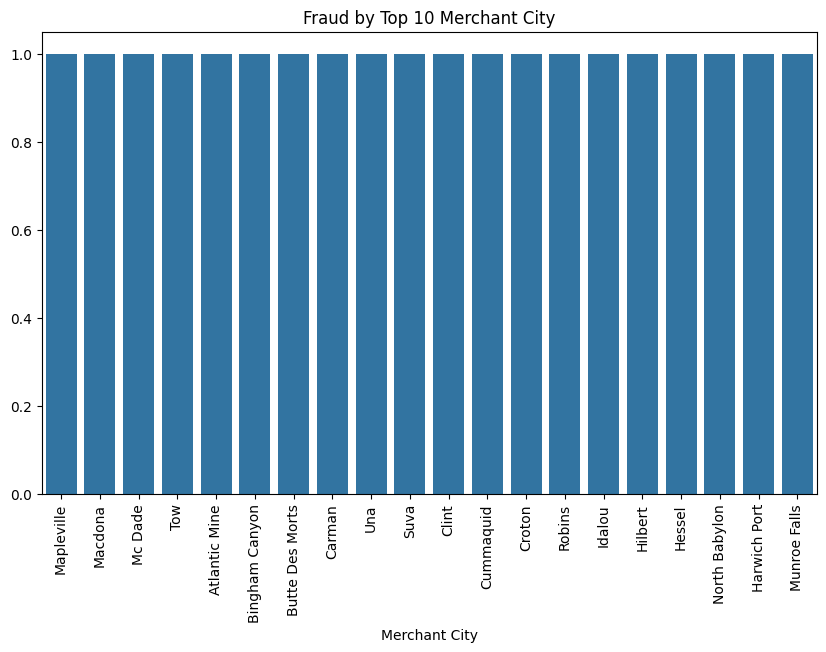

In [29]:
# Fraud by Merchant City (top 10 Cities by transaction count)
city_fraud_rate = CP_transaction.groupby("Merchant City")["Is Fraud?"].mean()
High_risk_cities = city_fraud_rate[
    city_fraud_rate > df["Is Fraud?"].mean()
].sort_values(ascending=False)

# select top 20 high risk cities
top_20_high_risk_cities = High_risk_cities.head(20)

# visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=top_20_high_risk_cities.index, y=top_20_high_risk_cities.values)
plt.title("Fraud by Top 10 Merchant City")
plt.xticks(rotation=90)
plt.show()

##Feature Engineered: High Risk State
This new feature flags cities with a fraud rate higher than the overall fraud rate of the dataset. Cities with a fraud rate greater than the overall rate are assigned a value of 1 (high risk), while others are assigned a value of 0 (low risk).

In [30]:
high_risk_cities_list = High_risk_cities.index.tolist()
df["High_risk_cities"] = df["Merchant City"].apply(
    lambda x: 1 if x in high_risk_cities_list else 0
)

## Feature: Card Brand

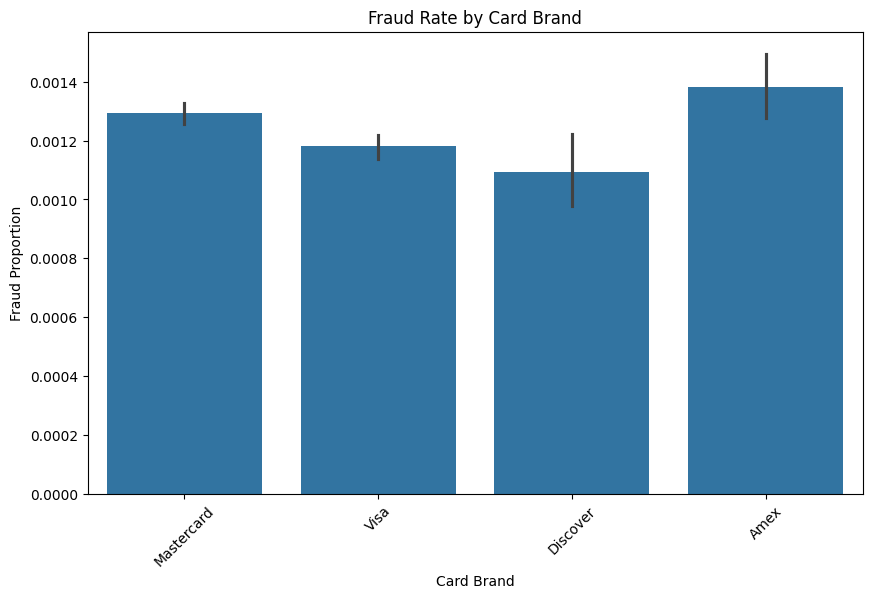

In [31]:
# Fraud rate by Card Brand
plt.figure(figsize=(10, 6))
sns.barplot(x="Card Brand", y="Is Fraud?", data=df, estimator=lambda x: sum(x) / len(x))
plt.title("Fraud Rate by Card Brand")
plt.ylabel("Fraud Proportion")
plt.xticks(rotation=45)
plt.show()

The result shows that there is no significant difference in fraud rates across different card brands. Fraud appears to be distributed relatively evenly among them.

## Feature: Card Type

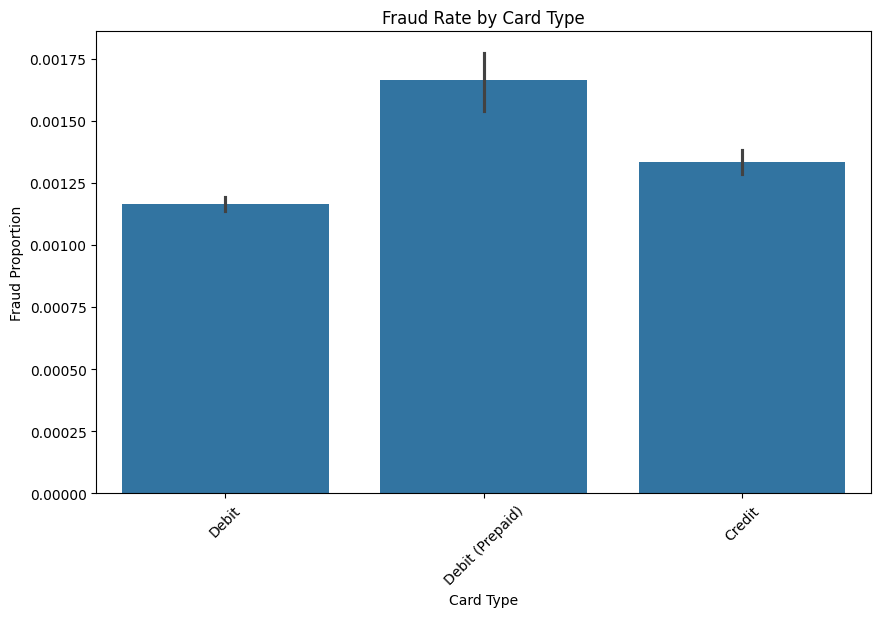

In [32]:
# Fraud rate by Card Type
plt.figure(figsize=(10, 6))
sns.barplot(x="Card Type", y="Is Fraud?", data=df, estimator=lambda x: sum(x) / len(x))
plt.title("Fraud Rate by Card Type")
plt.ylabel("Fraud Proportion")
plt.xticks(rotation=45)
plt.show()

he result shows that Prepaid Debit Cards have a higher fraud rate compared to other card types, which could be due to their higher usage in risky or untraceable transactions.

## Feature: Card on Dark Web

In [33]:
# Fraud rate by Card on Dark Web
print(df["Card on Dark Web"].unique())
# There are no cards listed on the Dark Web with a 'yes' status

['No']


there is no any transaction on dark web

## feature: Gender

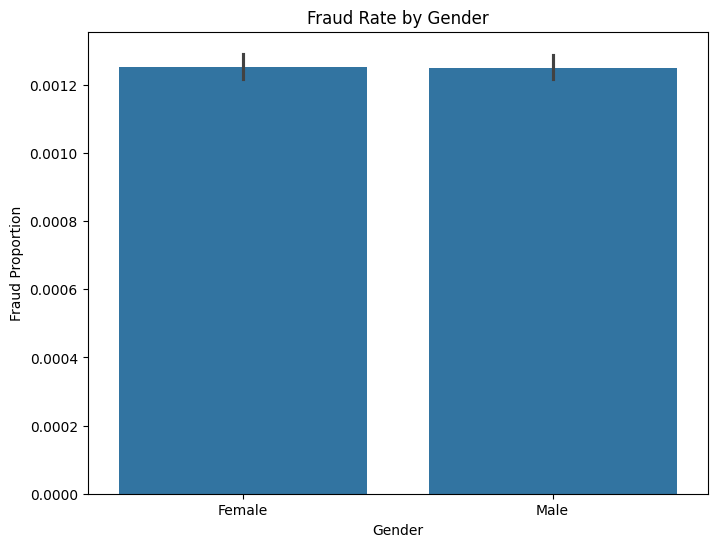

In [34]:
# Fraud rate by Gender
plt.figure(figsize=(8, 6))
sns.barplot(x="Gender", y="Is Fraud?", data=df, estimator=lambda x: sum(x) / len(x))
plt.title("Fraud Rate by Gender")
plt.ylabel("Fraud Proportion")
plt.show()

there is no significant difference in fraud rate between genders.

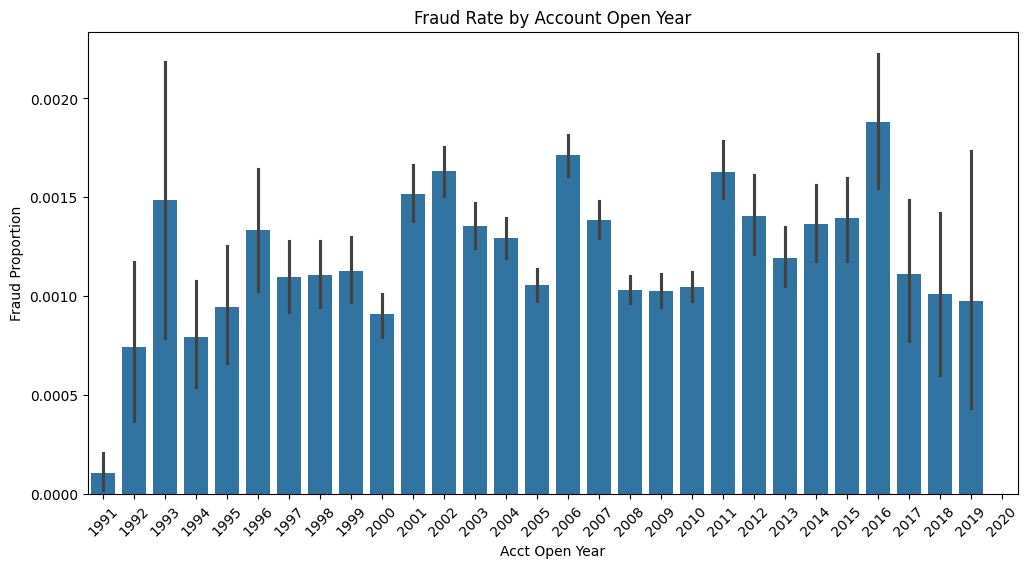

In [35]:
# Extract year from Acct Open Date
df["Acct Open Year"] = pd.to_datetime(df["Acct Open Date"]).dt.year
plt.figure(figsize=(12, 6))
sns.barplot(
    x="Acct Open Year", y="Is Fraud?", data=df, estimator=lambda x: sum(x) / len(x)
)
plt.title("Fraud Rate by Account Open Year")
plt.ylabel("Fraud Proportion")
plt.xticks(rotation=45)
plt.show()

## Feature: Error type

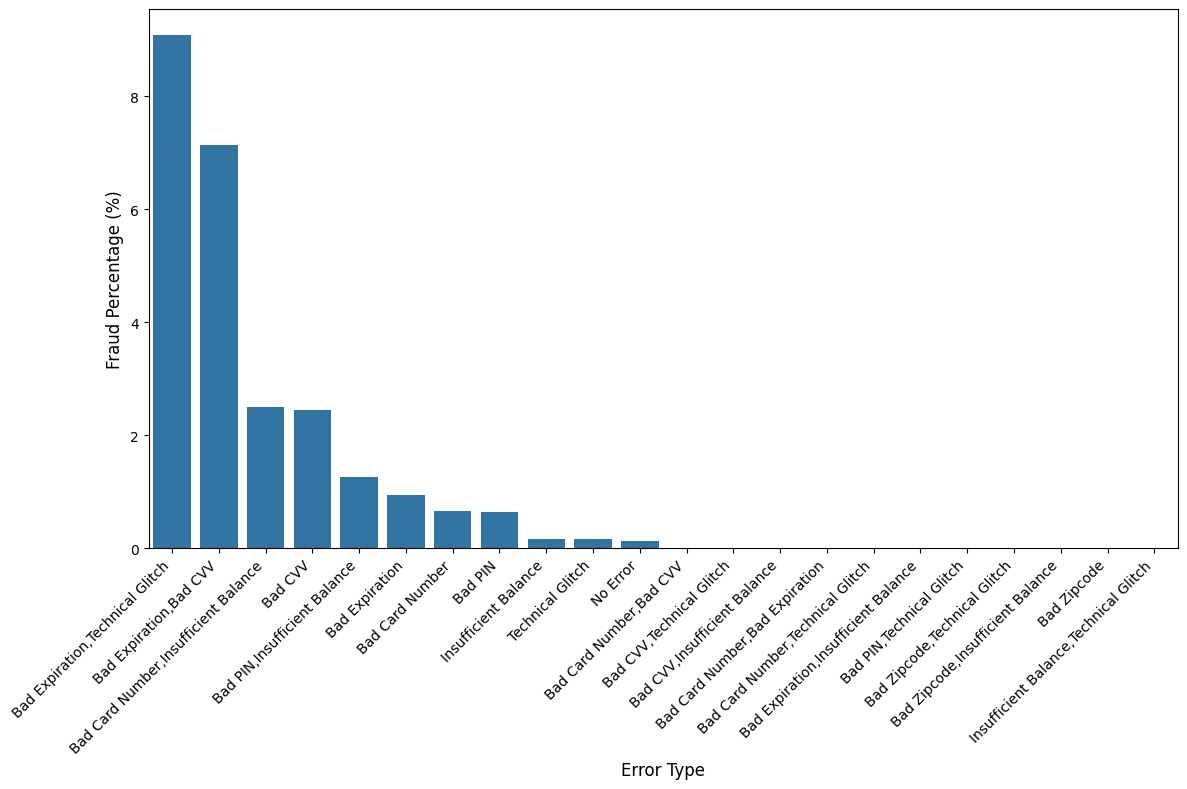

In [36]:
# Fraud rate by Error type
# count total occurance of each Error type
error_counts = df["Errors?"].value_counts()
error_counts

error_fraud_data = (
    df.groupby("Errors?")
    .agg(
        total_count=("Is Fraud?", "count"),
        fraud_count=("Is Fraud?", "sum"),
        fraud_percentage=("Is Fraud?", "mean"),
    )
    .reset_index()
)
error_fraud_data["fraud_percentage"] *= 100
plt.figure(figsize=(12, 8))
sns.barplot(
    x="Errors?",
    y="fraud_percentage",
    data=error_fraud_data,
    order=error_fraud_data.sort_values("fraud_percentage", ascending=False)["Errors?"],
)
plt.xlabel("Error Type", fontsize=12)
plt.ylabel("Fraud Percentage (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [37]:
error_fraud_data

,Errors?,total_count,fraud_count,fraud_percentage
0,Bad CVV,3363,82,2.438299
1,"Bad CVV,Insufficient Balance",23,0,0.000000
2,"Bad CVV,Technical Glitch",6,0,0.000000
3,Bad Card Number,4262,28,0.656969
4,"Bad Card Number,Bad CVV",14,0,0.000000
5,"Bad Card Number,Bad Expiration",14,0,0.000000
6,"Bad Card Number,Insufficient Balance",40,1,2.500000
7,"Bad Card Number,Technical Glitch",10,0,0.000000
8,Bad Expiration,3375,32,0.948148
9,"Bad Expiration,Bad CVV",14,1,7.142857


In [38]:
df.columns

Index(['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip',
       'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC',
       'Errors?', 'Is Fraud?', 'Current Age', 'Retirement Age', 'Birth Year',
       'Birth Month', 'Gender', 'Address', 'Apartment', 'City', 'State',
       'Zipcode', 'Latitude', 'Longitude', 'Per Capita Income - Zipcode',
       'Yearly Income - Person', 'Total Debt', 'FICO Score',
       'Num Credit Cards', 'Card Brand', 'Card Type', 'Card Number', 'Expires',
       'CVV', 'Has Chip', 'Cards Issued', 'Credit Limit', 'Acct Open Date',
       'Year PIN last Changed', 'Card on Dark Web', 'Transaction Hour',
       'timestamp', 'Date', 'Day_of_Week', 'Transaction_type',
       'High_risk_state', 'High_risk_cities', 'Acct Open Year'],
      dtype='object')

## Fraud analysis based on age

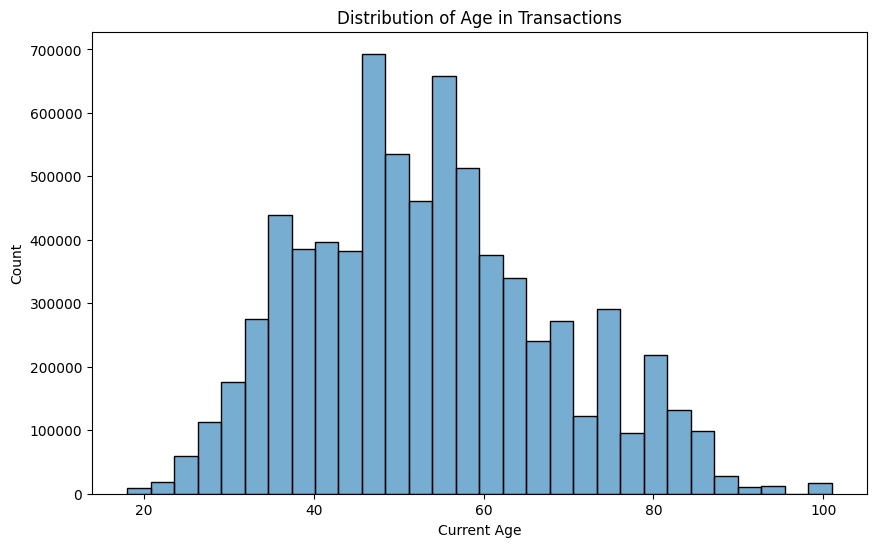

In [39]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Current Age", bins=30, alpha=0.6)
plt.xlabel("Current Age")
plt.ylabel("Count")
plt.title("Distribution of Age in Transactions")
plt.show()

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\1960957199.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate_by_age_group = df.groupby('Age Group').agg(


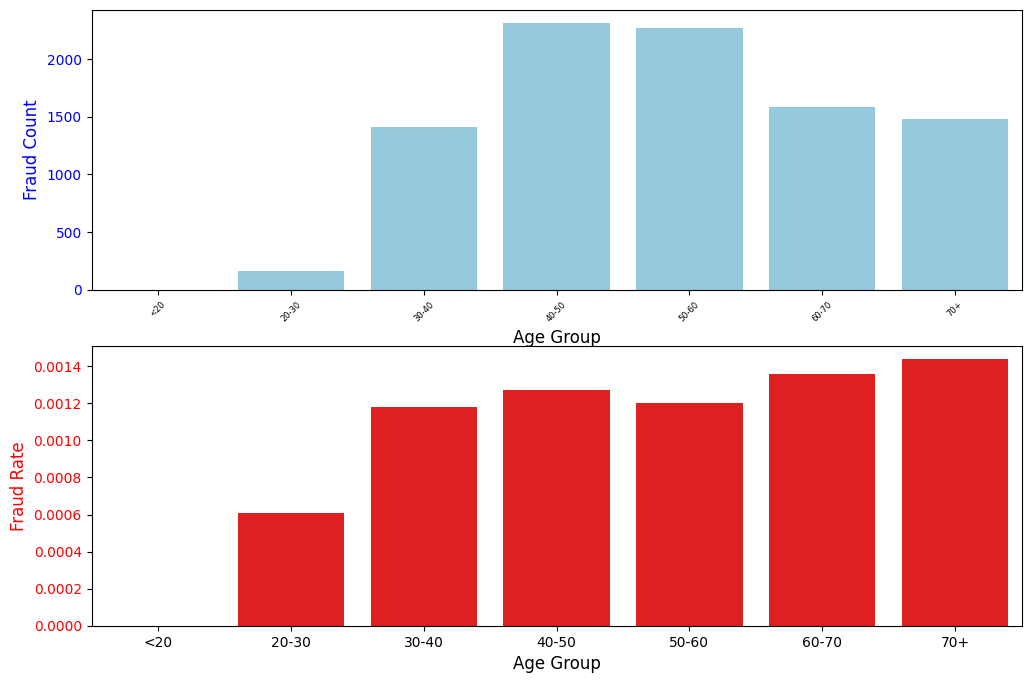

In [40]:
# calculate fraude rate per age group
df["Age Group"] = pd.cut(
    df["Current Age"],
    bins=[0, 20, 30, 40, 50, 60, 70, 110],
    labels=["<20", "20-30", "30-40", "40-50", "50-60", "60-70", "70+"],
)

fraud_rate_by_age_group = (
    df.groupby("Age Group")
    .agg(
        total_count=("Is Fraud?", "count"),
        fraud_count=("Is Fraud?", "sum"),
        fraud_percentage=("Is Fraud?", "mean"),
    )
    .reset_index()
)


# fraud count by months
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
sns.barplot(
    x="Age Group",
    y="fraud_count",
    data=fraud_rate_by_age_group,
    ax=axes[0],
    color="skyblue",
)
axes[0].set_xlabel("Age Group", fontsize=12)
axes[0].set_ylabel("Fraud Count", fontsize=12, color="blue")
axes[0].tick_params(axis="y", labelcolor="blue")
axes[0].tick_params(axis="x", rotation=45, labelsize=6)

# fraud rate by months
sns.barplot(
    x="Age Group",
    y="fraud_percentage",
    data=fraud_rate_by_age_group,
    ax=axes[1],
    color="red",
)
axes[1].set_xlabel("Age Group", fontsize=12)
axes[1].set_ylabel("Fraud Rate", fontsize=12, color="red")
axes[1].tick_params(axis="y", labelcolor="red")

There is no significant difference in fraud rates across different age groups, except for the 20-30 age group, which shows a slightly lower fraud rate compared to others.

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\195534816.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is Fraud?', y='Current Age', palette="coolwarm")


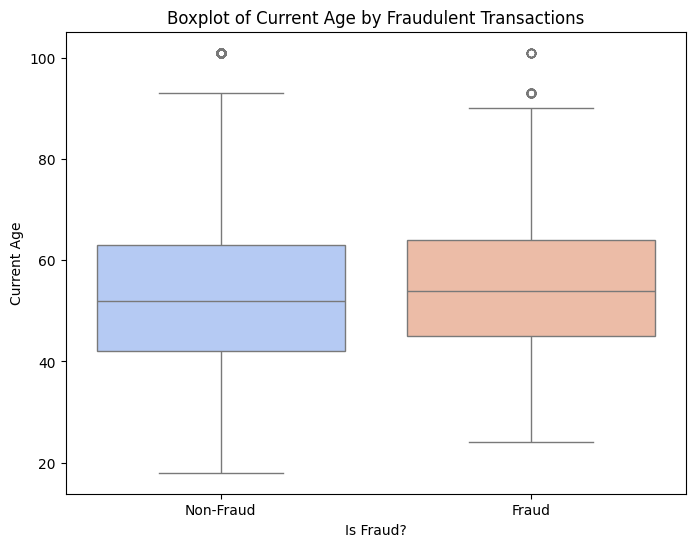

In [41]:
# Comparison of Age Distribution Between Fraud and Non-Fraud Transactions
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Is Fraud?", y="Current Age", palette="coolwarm")
plt.xlabel("Is Fraud?")
plt.ylabel("Current Age")
plt.title("Boxplot of Current Age by Fraudulent Transactions")
plt.xticks(ticks=[0, 1], labels=["Non-Fraud", "Fraud"])
plt.show()

## Feature: Retirement Age

Text(0, 0.5, 'Count')

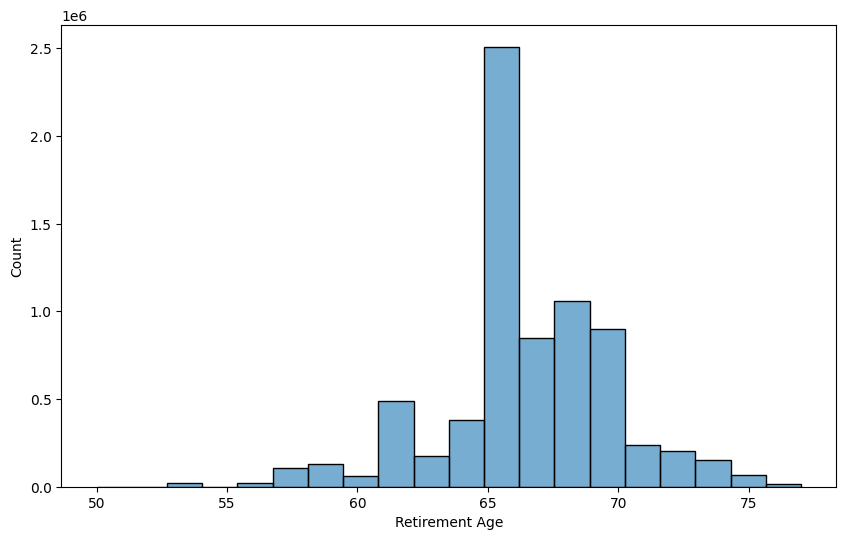

In [42]:
# check distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Retirement Age", bins=20, alpha=0.6)
plt.xlabel("Retirement Age")
plt.ylabel("Count")

In [43]:
# compared retired vs working users
df["Is Retired"] = (df["Retirement Age"] <= df["Current Age"]).astype(int)
df.groupby("Is Retired")["Is Fraud?"].mean()

Is Retired
0    0.001203
1    0.001428
Name: Is Fraud?, dtype: float64

The results show a slight difference in fraud rate between retired and working users. This difference may be explained by factors such as retired users being less familiar with digital payment systems, potentially making them more vulnerable to fraud attempts. Additionally, fraudsters might perceive retired users as having stable savings or pension incomes, making them attractive targets.

In [44]:
# fraud rate by retirement proximity
df["Years to retirement"] = np.where(
    df["Is Retired"] == 0,
    df["Retirement Age"] - df["Current Age"],
    np.nan,  # is retired
)

# Bin working users by retirement proximity
df["Retirement Proximity"] = pd.cut(
    df["Years to retirement"], bins=[0, 5, 10, 20, np.inf]
)

# Fraud rate by proximity
df.groupby("Retirement Proximity")["Is Fraud?"].mean()

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\3803421137.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Retirement Proximity')['Is Fraud?'].mean()


Retirement Proximity
(0.0, 5.0]      0.001407
(5.0, 10.0]     0.001189
(10.0, 20.0]    0.001281
(20.0, inf]     0.001097
Name: Is Fraud?, dtype: float64

There is no significant difference in fraud rate based on retirement proximity. However, customers who are closer to their retirement age show a slightly higher fraud rate. This could be explained by factors such as lower digital literacy or the possibility that fraudsters target these customers assuming they have accumulated retirement savings.

In [45]:
# analysis for retired users

# years since retirement
df["Years Since Retirement"] = np.where(
    df["Is Retired"] == 1, -df["Retirement Age"] + df["Current Age"], np.nan
)

# Bin Retired Users
df["Retirement Phase"] = pd.cut(
    df["Years Since Retirement"], bins=[0, 5, 10, 20, np.inf]
)

# Fraud rate by retirement phase
df.groupby("Retirement Phase")["Is Fraud?"].mean()

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\71235250.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Retirement Phase')['Is Fraud?'].mean()


Retirement Phase
(0.0, 5.0]      0.001774
(5.0, 10.0]     0.001475
(10.0, 20.0]    0.001254
(20.0, inf]     0.001294
Name: Is Fraud?, dtype: float64

The analysis shows that users in the early phase of retirement have a higher fraud rate. This could be because newly retired users are still adjusting to managing their finances independently, often relying more on online transactions or unfamiliar digital tools. Additionally, fraudsters may target this group assuming they have access to retirement savings while possibly lacking strong digital security habits. Alternatively, the significant life change of retirement might lead to financial stress, increasing the risk of falling for fraudulent schemes.

## Feature: Income





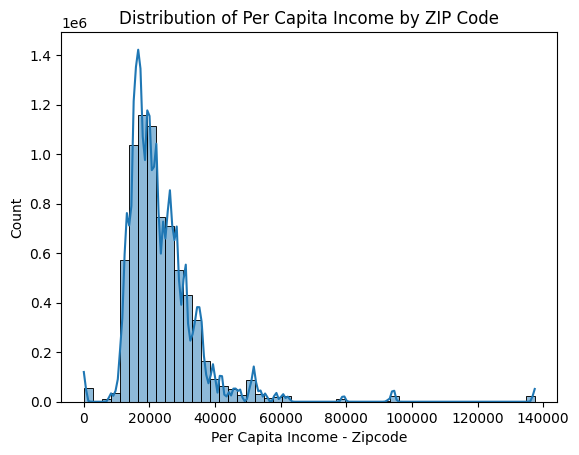

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\788487134.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_bin_data = df.groupby('Zip Income Tier')['Is Fraud?'].mean().reset_index()


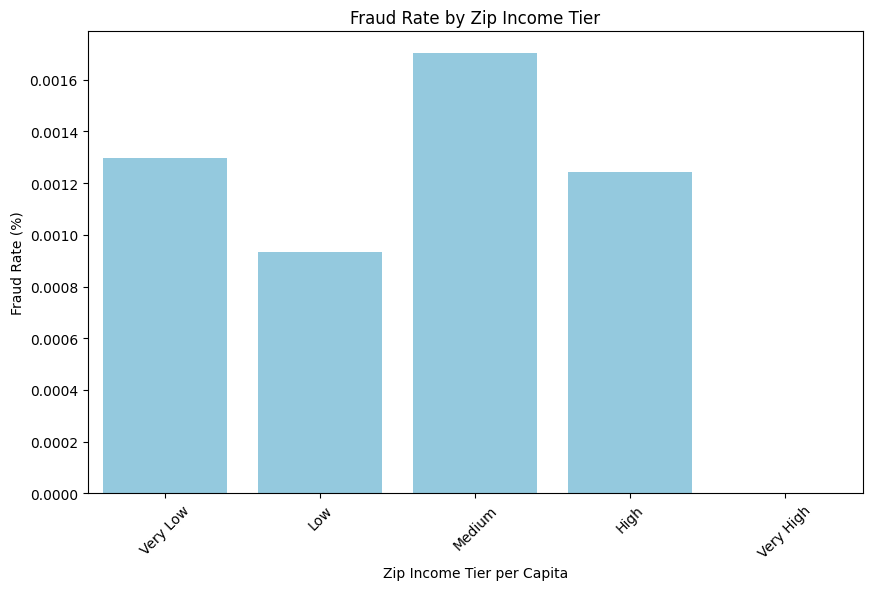

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\788487134.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_bin_data_count = df.groupby('Zip Income Tier')['Is Fraud?'].sum().reset_index()


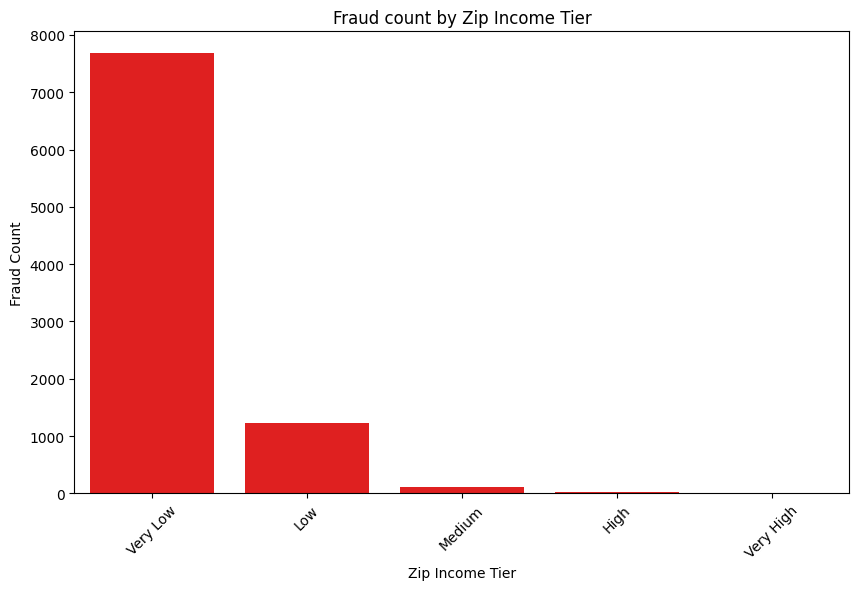

In [46]:
# fraud analysis by per capita income

# Distribution plot
sns.histplot(df["Per Capita Income - Zipcode"], bins=50, kde=True)
plt.title("Distribution of Per Capita Income by ZIP Code")
plt.show()


# Create zip income tier (e.g., every $10,000)
df["Zip Income Tier"] = pd.cut(
    df["Per Capita Income - Zipcode"],
    bins=[0, 30000, 60000, 100000, 200000, np.inf],
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
)

# Group by Zip Income Tier and calculate average fraud rate
income_bin_data = df.groupby("Zip Income Tier")["Is Fraud?"].mean().reset_index()
# Plot fraud rate by income bins
plt.figure(figsize=(10, 6))
sns.barplot(x="Zip Income Tier", y="Is Fraud?", data=income_bin_data, color="skyblue")
plt.xlabel("Zip Income Tier per Capita")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Zip Income Tier")
plt.xticks(rotation=45)
plt.show()

# Plot fraud count by Zip Income Tier
income_bin_data_count = df.groupby("Zip Income Tier")["Is Fraud?"].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x="Zip Income Tier", y="Is Fraud?", data=income_bin_data_count, color="red")
plt.xlabel("Zip Income Tier")
plt.ylabel("Fraud Count")
plt.title("Fraud count by Zip Income Tier")
plt.xticks(rotation=45)
plt.show()

The fraud rate is nearly the same across all income bins, but the rate is slightly higher for the per capita income range between $60,000 and $100,000.

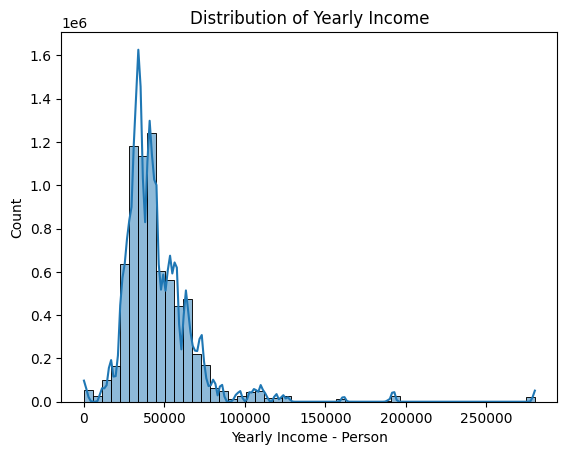

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\3281331652.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_income = df.groupby('income_tier')['Is Fraud?'].mean()


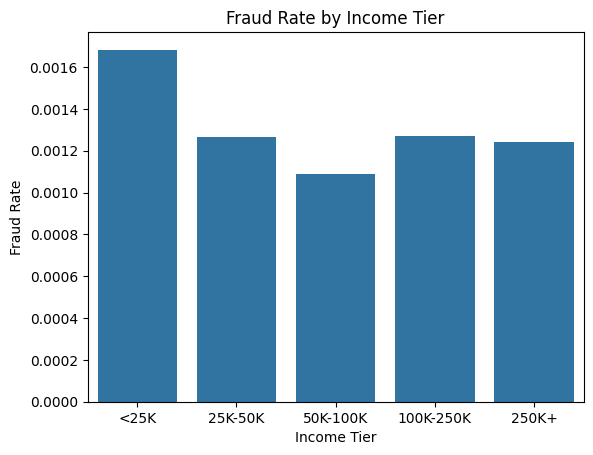

In [47]:
# Fraud analysis based on Yearly Income - Person

# Distribution plot
sns.histplot(df["Yearly Income - Person"], bins=50, kde=True)
plt.title("Distribution of Yearly Income")
plt.show()

# Bin into income groups
df["income_tier"] = pd.cut(
    df["Yearly Income - Person"],
    bins=[0, 25000, 50000, 100000, 250000, np.inf],
    labels=["<25K", "25K-50K", "50K-100K", "100K-250K", "250K+"],
)
# Fraud rate by tier
fraud_by_income = df.groupby("income_tier")["Is Fraud?"].mean()
sns.barplot(x=fraud_by_income.index, y=fraud_by_income.values)
plt.title("Fraud Rate by Income Tier")
plt.xlabel("Income Tier")
plt.ylabel("Fraud Rate")
plt.show()

The result shows that users with low income (less than $25k per year) have a higher fraud rate. This could be attributed to several factors. Individuals with lower incomes may experience financial stress, making them more susceptible to fraud schemes promising quick financial relief. Moreover, they might have limited access to financial protection services like fraud monitoring or identity theft protection, which are often more readily available to higher-income individuals. Additionally, low-income users may lack financial literacy, making them more vulnerable to phishing, scams, and other fraudulent activities. Fraudsters may also specifically target this group, assuming they are less familiar with financial scams or have fewer resources to recover from fraudulent losses.

Text(0.5, 1.0, 'Fraud Rate for High Risk Transaction')

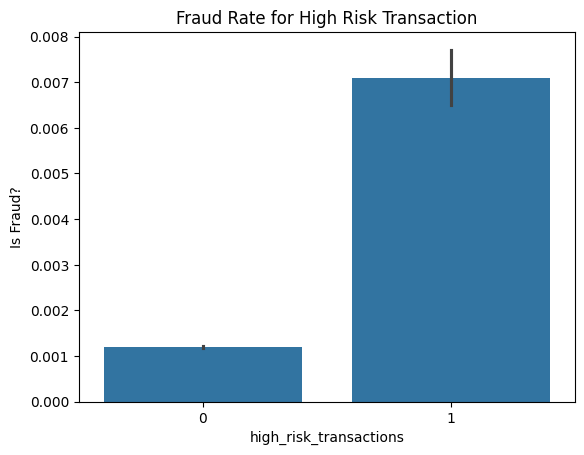

In [48]:
# Income mismatch
# Transaction amount as % of personal income
df["amount_income_ratio"] = df["Amount"] / df["Yearly Income - Person"]
df["amount_income_ratio"]

# flag outliers( top 1 % of amount/income )
threshold = df["amount_income_ratio"].quantile(0.99)

df["high_risk_transactions"] = (df["amount_income_ratio"] > threshold).astype(int)

# fraud rate for users spending high amount of yearly income in one transaction
sns.barplot(x="high_risk_transactions", y="Is Fraud?", data=df)
plt.title("Fraud Rate for High Risk Transaction")

In [49]:
# Compare user income to ZIP average
df["income_relative_to_zip"] = (
    df["Yearly Income - Person"] / df["Per Capita Income - Zipcode"]
)

# Fraud rate for users earning significantly more/less than neighbors
df["income_mismatch"] = pd.cut(
    df["income_relative_to_zip"],
    bins=[0, 0.5, 0.8, 1.2, 2, np.inf],
    labels=["<50%", "50-80%", "80-120%", "120-200%", ">200%"],
)
print(df.groupby("income_mismatch")["Is Fraud?"].mean())

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\2070694526.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('income_mismatch')['Is Fraud?'].mean())


income_mismatch
<50%             NaN
50-80%      0.001783
80-120%     0.001741
120-200%    0.001175
>200%       0.001234
Name: Is Fraud?, dtype: float64


The analysis shows that users whose income is significantly lower than the average income of their neighborhood (between 50% to 80% of the area’s average) tend to have a higher fraud rate. One possible explanation is that these users might feel financial pressure to maintain a similar lifestyle or consumption pattern as their neighbors, potentially increasing the likelihood of engaging in fraudulent activities to compensate for their lower income. Additionally, the slightly higher fraud rate among users with income between 80% to 120% of their area average could suggest that fraudsters often aim to mimic the typical profile of residents in a given area to avoid suspicion and appear more legitimate during fraudulent transactions.

## Feature: Total Debt

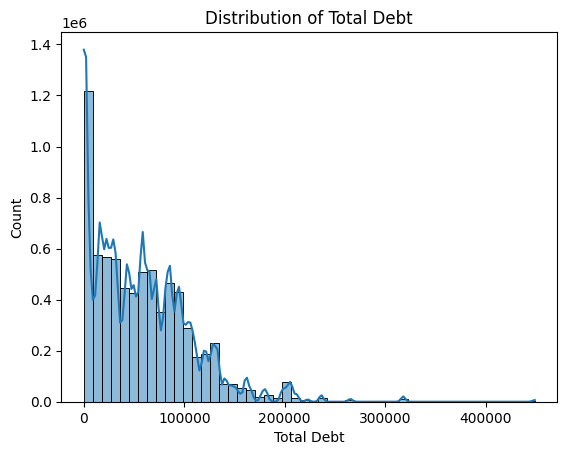

In [50]:
# Distribution plot
sns.histplot(df["Total Debt"], bins=50, kde=True)
plt.title("Distribution of Total Debt")
plt.show()

In [51]:
# fraud rate analysis by calculation debt to income ratio (Debt-To-Income(DTI))
df["debt_to_income"] = df["Total Debt"] / df["Yearly Income - Person"]
df["high_debt_ratio"] = (df["debt_to_income"] > 2).astype(int)
df.groupby("high_debt_ratio")["Is Fraud?"].agg(["mean", "count", "sum"])

,mean,count,sum
high_debt_ratio,,,
0,0.001250,5672009,7089
1,0.001256,1702870,2139


fraud rate remains consistent across different Debt-to-Income (DTI) levels, suggesting that DTI may not be a significant predictor of fraudulent activity in this dataset.

In [52]:
# Flag users with high debt making large purchases
df["high_debt_high_spend"] = (
    (df["Total Debt"] > 0.5 * df["Yearly Income - Person"])
    & (df["Amount"] > 0.1 * df["Yearly Income - Person"])
).astype(int)

# Fraud rate for this group
df.groupby("high_debt_high_spend")["Is Fraud?"].mean()

high_debt_high_spend
0    0.001244
1    0.068477
Name: Is Fraud?, dtype: float64

The analysis shows that transactions with both high debt levels of user and high amounts have a significantly higher fraud rate compared to others. This could be because users who are financially stressed or over-leveraged might be more motivated to commit fraud in order to manage their debt or sustain their spending habits.

In [53]:
# analyzing relationship between credit limit utilization and fraud
df["credit_utilization"] = df["Total Debt"] / df["Credit Limit"]
df["credit_utilization"].replace(
    [np.inf, -np.inf], np.nan, inplace=True
)  # because some credit limits are zero
df.groupby("credit_utilization")["Is Fraud?"].agg(["mean", "median"])

df["credit_util_bin"] = pd.cut(
    df["credit_utilization"],
    bins=[0, 0.1, 0.3, 0.5, 0.7, np.inf],
    labels=["Very Low", "Low", "Medium", "High", "Maxed Out"],
)
df.groupby("credit_util_bin")["Is Fraud?"].mean()

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\2863264678.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_utilization'].replace([np.inf, -np.inf], np.nan, inplace=True) # because some credit limits are zero
C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\2863264678.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df

credit_util_bin
Very Low     0.001245
Low          0.000991
Medium       0.001245
High         0.001410
Maxed Out    0.001252
Name: Is Fraud?, dtype: float64

Based on the data, there does not appear to be a significant difference in fraud rates between low and high credit utilization levels.

## Feature: FICO score

In [54]:
# Fraud analysis based on FICO Score

# Bin FICO scores into tiers
df["fico_tier"] = pd.cut(
    df["FICO Score"],
    bins=[300, 580, 670, 740, 800, 850],
    labels=[
        "Poor (<580)",
        "Fair (580-669)",
        "Good (670-739)",
        "Very Good (740-799)",
        "Exceptional (800+)",
    ],
)

# Fraud rate by tier
df.groupby("fico_tier")["Is Fraud?"].agg(["mean", "sum", "count"])

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\2957720510.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('fico_tier')['Is Fraud?'].agg(['mean','sum','count'])


,mean,sum,count
fico_tier,,,
Poor (<580),0.000929,217,233571
Fair (580-669),0.000975,1033,1059063
Good (670-739),0.001210,4592,3794612
Very Good (740-799),0.001438,2594,1803803
Exceptional (800+),0.001637,792,483830


In general, we expect that users with a higher FICO score would be more financially responsible and thus less likely to commit fraud. However, the analysis shows that as the FICO score increases, the fraud rate also increases. One possible explanation is that fraudsters intentionally target or impersonate users with high FICO scores because these profiles are considered more trustworthy by financial institutions. High FICO score accounts are more likely to get approved for larger transactions, loans, or credit limits, making them more attractive targets for fraud. Additionally, in cases of synthetic identity fraud, fraudsters may try to build a fake but 'strong' credit profile with a high FICO score before committing fraud, which could explain this pattern in the data.

In [55]:
# Flag large transactions from low-FICO users
df["low_fico_high_spend"] = (
    (df["FICO Score"] < 671) & (df["Amount"] > 0.1 * df["Yearly Income - Person"])
).astype(int)

# Fraud rate for this group
df.groupby("low_fico_high_spend")["Is Fraud?"].agg(["mean", "sum", "count"])

,mean,sum,count
low_fico_high_spend,,,
0,0.001252,9213,7357556
1,0.000866,15,17323


In my analysis, I investigated transactions where users have relatively low income, and the transaction amount exceeds one-tenth of their yearly income. Intuitively, I expected these transactions to have a higher fraud rate, given the unusually large spend relative to their financial capacity. However, the results did not support this assumption. One possible explanation is that, in this dataset, transactions associated with higher FICO scores tend to have a higher fraud rate. Since I had already filtered the data to include only users with FICO scores below 670 (low credit score users), this might have reduced the likelihood of fraud within this specific group, affecting the overall result.

In [56]:
# Analyzing the relationship between Low FICO and high DTI
df["Low_FICO_High_DTI"] = (
    (df["FICO Score"] < 670) & (df["debt_to_income"] > 2)
).astype(int)
df.groupby("Low_FICO_High_DTI")["Is Fraud?"].agg(["mean", "sum", "count"])

,mean,sum,count
Low_FICO_High_DTI,,,
0,0.001267,8965,7076050
1,0.000880,263,298829


In [57]:
# potential synthetic fraud by creating a new feature called synthetic_risk which flags transactions (Synthetic fraudsters often build fake identities with "good but not perfect" FICO scores and move frequently to avoid detection.)
# Convert the dates to datetime
df["Acct Open Date"] = pd.to_datetime(df["Acct Open Date"])
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Calculate the difference in years between account open date and transaction date
df["account_tenure_years"] = -(df["Acct Open Date"] - df["timestamp"]).dt.days / 365

# Synthetic fraud often targets "Good" FICO ranges (670–739)
df["synthetic_risk"] = (
    (df["FICO Score"] >= 740) & (df["account_tenure_years"] < 2)  # Short tenure
).astype(int)
df.groupby("synthetic_risk")["Is Fraud?"].agg(["mean", "sum", "count"])

,mean,sum,count
synthetic_risk,,,
0,0.001238,8496,6861109
1,0.001425,732,513770


 Synthetic identity fraudsters often construct credit profiles that appear legitimate by achieving high credit scores in a short period. They may do this by becoming authorized users on existing accounts or by making small purchases and timely payments to build creditworthiness quickly. Despite the high credit score, these synthetic identities typically have a "thin file," meaning a short or limited credit history. ​

The analysis shows a slightly higher fraud rate for transactions tagged with synthetic risk.

In [58]:
# Comparing the fraud rate across different FICO tiers for accounts with less than 2 year of tenure.
df[df["account_tenure_years"] < 2].groupby("fico_tier")["Is Fraud?"].agg(
    ["mean", "sum", "count"]
)

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\1413068957.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['account_tenure_years'] <2].groupby('fico_tier')['Is Fraud?'].agg(['mean','sum','count'])


,mean,sum,count
fico_tier,,,
Poor (<580),0.001084,55,50722
Fair (580-669),0.000963,208,216096
Good (670-739),0.001047,931,889495
Very Good (740-799),0.001409,575,408138
Exceptional (800+),0.001489,157,105407


This shows the effect of synthetic identity fraudesters on high fico scores

## Feature: Number of Credit Cards

[5 6 2 4 1 3 7 8]


Text(0.5, 1.0, 'Fraud count by number of credit cards')

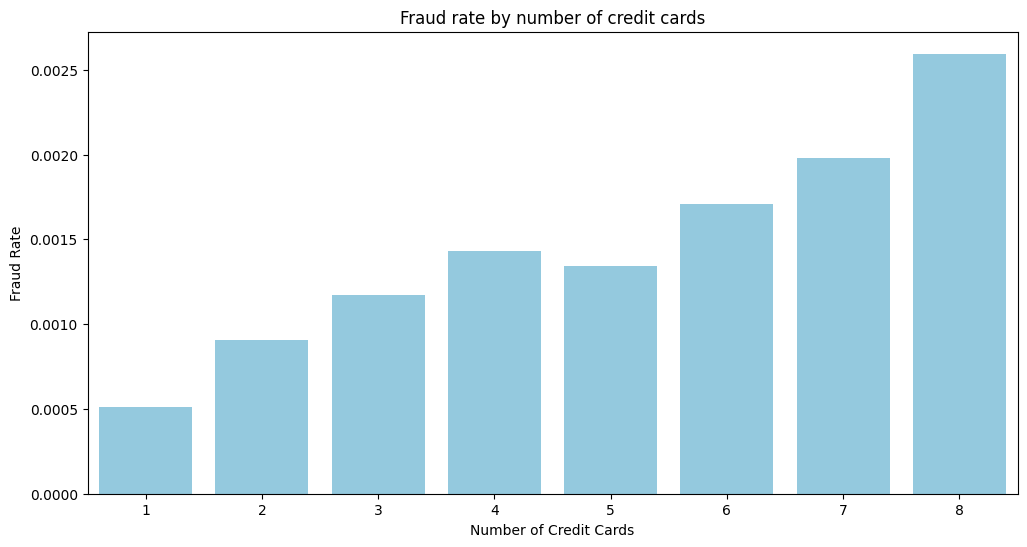

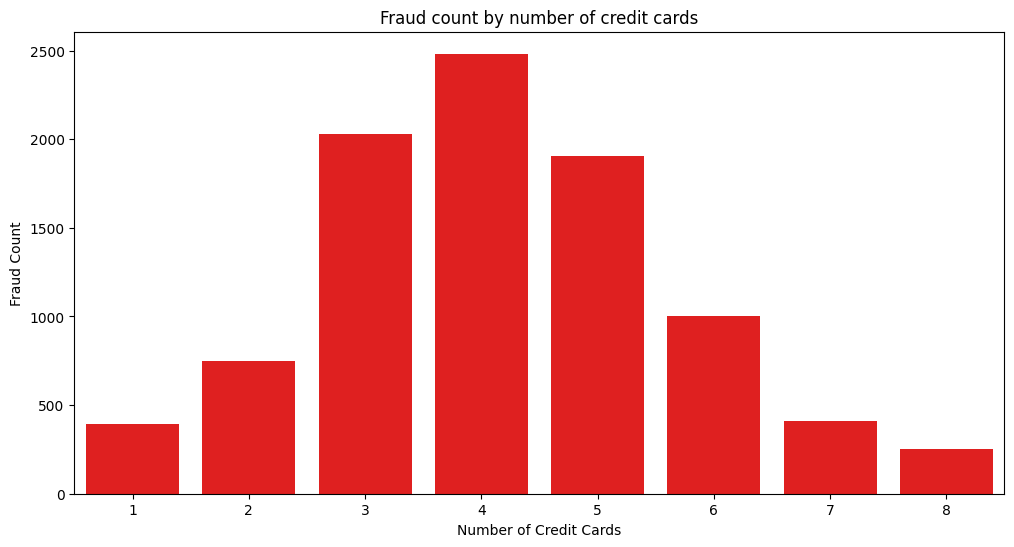

In [59]:
# fraud analysis based on number of credit cards
ncredit_fraud_data = df.groupby("Num Credit Cards").agg(
    fraud_count=("Is Fraud?", "sum"), fraud_rate=("Is Fraud?", "mean")
)

print(df["Num Credit Cards"].unique())

# plot fraud rate based on number of credit card
plt.figure(figsize=(12, 6))
sns.barplot(
    x="Num Credit Cards", y="fraud_rate", data=ncredit_fraud_data, color="skyblue"
)
plt.xlabel("Number of Credit Cards")
plt.ylabel("Fraud Rate")
plt.title("Fraud rate by number of credit cards")

# plot fraud count based on number of credit card
plt.figure(figsize=(12, 6))
sns.barplot(x="Num Credit Cards", y="fraud_count", data=ncredit_fraud_data, color="red")
plt.xlabel("Number of Credit Cards")
plt.ylabel("Fraud Count")
plt.title("Fraud count by number of credit cards")

The increased fraud rate associated with a higher number of credit cards indicates a greater risk of synthetic fraud

In [60]:
# To check whether having more than 4 credit cards combined with a high debt ratio increases fraud risk
df[df["Num Credit Cards"] > 4].groupby("high_debt_ratio")["Is Fraud?"].agg(
    ["mean", "sum", "count"]
)

# feature engineering:

df["synthetic_risk_2"] = (
    (df["Num Credit Cards"] > 4) & (df["high_debt_ratio"] == 1)
).astype(int)

df.groupby("synthetic_risk_2")["Is Fraud?"].agg(["mean", "sum", "count"])

,mean,sum,count
synthetic_risk_2,,,
0,0.001210,8374,6918820
1,0.001873,854,456059


The analysis shows that users who have more than 4 credit cards combined with a high debt ratio experience a higher fraud rate. This suggests that such financial behavior may indicate riskier profiles, possibly associated with synthetic identity fraud or financial stress-related fraud patterns.

## Feature: MCC

In [61]:
df["MCC"].nunique()

109

In [64]:
# defining high risk MCC
High_risk_MCC = MCC_fraud_data[
    MCC_fraud_data["fraud_rate"] > df["Is Fraud?"].mean()
].index.to_list()
len(High_risk_MCC)
df["High_risk_MCC"] = df["MCC"].apply(lambda x: 1 if x in High_risk_MCC else 0)
# comparing fraud rate between high risk and low risk mcc
df.groupby("High_risk_MCC")["Is Fraud?"].agg(["mean", "sum", "count"])

,mean,sum,count
High_risk_MCC,,,
0,0.000297,1691,5692351
1,0.004480,7537,1682528


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39],
 [Text(0, 0, '5921'),
  Text(1, 0, '4214'),
  Text(2, 0, '5655'),
  Text(3, 0, '5211'),
  Text(4, 0, '4829'),
  Text(5, 0, '5970'),
  Text(6, 0, '5300'),
  Text(7, 0, '7995'),
  Text(8, 0, '8062'),
  Text(9, 0, '5251'),
  Text(10, 0, '7531'),
  Text(11, 0, '3640'),
  Text(12, 0, '5621'),
  Text(13, 0, '7922'),
  Text(14, 0, '3260'),
  Text(15, 0, '5719'),
  Text(16, 0, '5661'),
  Text(17, 0, '3393'),
  Text(18, 0, '3066'),
  Text(19, 0, '5310'),
  Text(20, 0, '3771'),
  Text(21, 0, '5311'),
  Text(22, 0, '3174'),
  Text(23, 0, '3405'),
  Text(24, 0, '7801'),
  Text(25, 0, '5947'),
  Text(26, 0, '4722'),
  Text(27, 0, '3387'),
  Text(28, 0, '3509'),
  Text(29, 0, '3359'),
  Text(30, 0, '5651'),
  Text(31, 0, '3256'),
  Text(32, 0, '3730'),
  Text(33, 0, '5815'

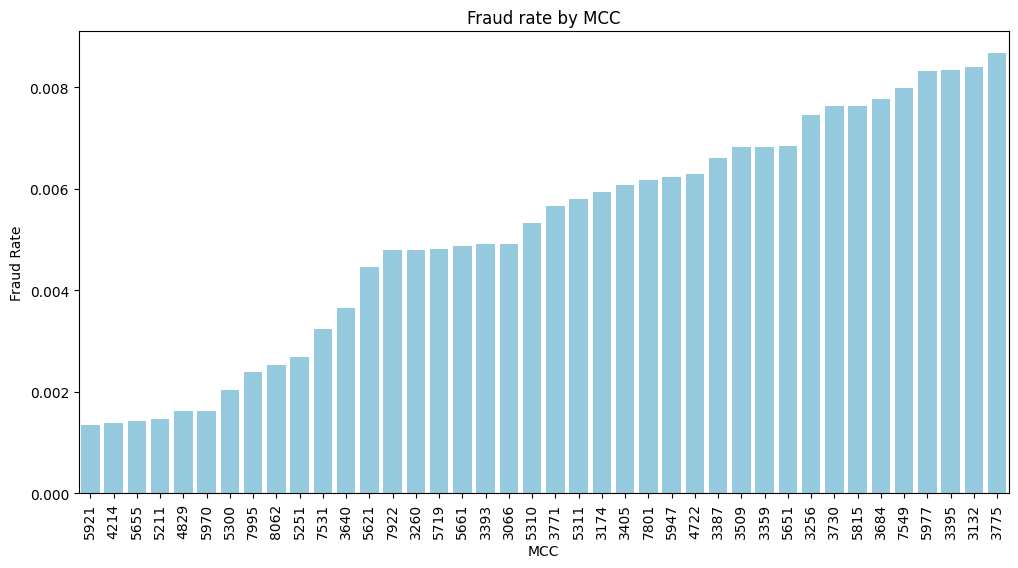

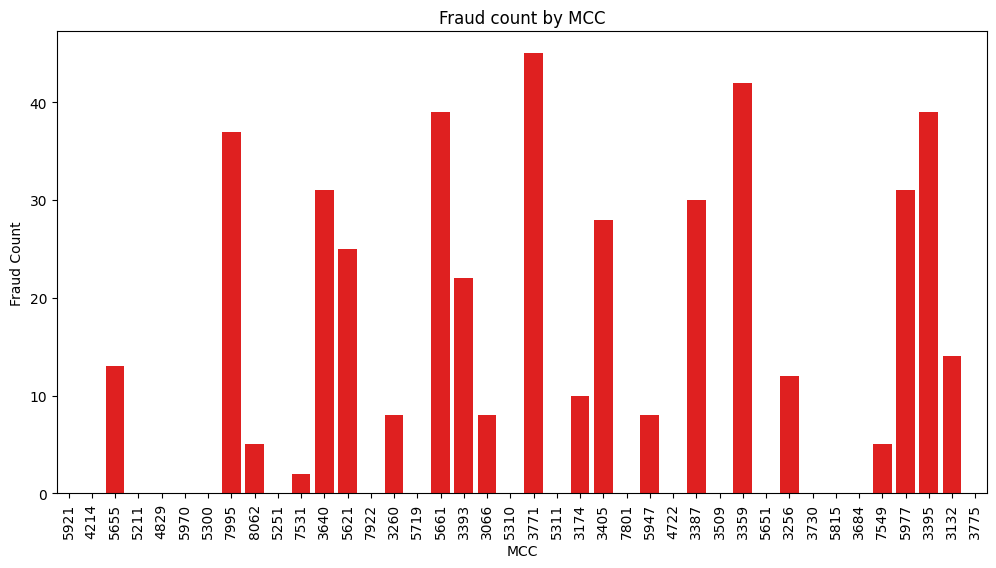

In [63]:
# Fraud Analysis based on MCC( Merchant category code)

MCC_fraud_data = df.groupby("MCC").agg(
    fraud_count=("Is Fraud?", "sum"), fraud_rate=("Is Fraud?", "mean")
)
High_risk_MCC_Fraud_Data = MCC_fraud_data[
    MCC_fraud_data["fraud_rate"] > df["Is Fraud?"].mean()
].reset_index()
High_risk_MCC_Fraud_Data
# plot fraud rate based on MCC
plt.figure(figsize=(12, 6))
sns.barplot(
    x="MCC",
    y="fraud_rate",
    data=High_risk_MCC_Fraud_Data.sort_values(by="fraud_rate").head(40),
    order=High_risk_MCC_Fraud_Data.sort_values(by="fraud_rate").head(40)["MCC"],
    color="skyblue",
)
plt.xlabel("MCC")
plt.ylabel("Fraud Rate")
plt.title("Fraud rate by MCC")
plt.xticks(rotation=90)

# plot fraud count based on number of credit card
plt.figure(figsize=(12, 6))
sns.barplot(
    x="MCC",
    y="fraud_count",
    data=High_risk_MCC_Fraud_Data.sort_values(by="fraud_count").head(40),
    order=High_risk_MCC_Fraud_Data.sort_values(by="fraud_rate").head(40)["MCC"],
    color="red",
)
plt.xlabel("MCC")
plt.ylabel("Fraud Count")
plt.title("Fraud count by MCC")
plt.xticks(rotation=90)

This analysis identifies MCCs (Merchant Category Codes) that are more suspicious and associated with a higher likelihood of fraudulent transactions. The results clearly indicate a significant difference in fraud rates between high-risk MCCs and other MCCs, highlighting certain merchant categories as more vulnerable to fraud.

### MCC Transaction vs. Amount

In [65]:
# Compare median transaction amount for fraud vs. non-fraud based on MCC
mcc_stats = df.groupby(["MCC", "Is Fraud?"])["Amount"].mean().unstack()

mcc_stats.columns = ["legit_median_amt", "fraud_median_amt"]

mcc_stats["amt_diff"] = mcc_stats["fraud_median_amt"] - mcc_stats["legit_median_amt"]

# MCCs where fraud transactions are significantly higher
print(mcc_stats.sort_values("amt_diff", ascending=False))

      legit_median_amt  fraud_median_amt    amt_diff
MCC                                                 
7531        378.102853        641.080000  262.977147
8011        185.346212        399.421667  214.075455
5533        383.120998        568.012941  184.891943
7549        375.012061        544.554000  169.541939
4814        112.444136        267.664773  155.220637
...                ...               ...         ...
7276        181.976502               NaN         NaN
7393         30.821283               NaN         NaN
8049        146.377557               NaN         NaN
8111        478.993828               NaN         NaN
8931        182.839303               NaN         NaN

[109 rows x 3 columns]


If fraud transactions are much higher than normal, it could indicate big-ticket fraud (e.g., luxury scams).

If fraud transactions are much lower, it might suggest card testing (small purchases to check validity)

### User behavior analysis (MCC)

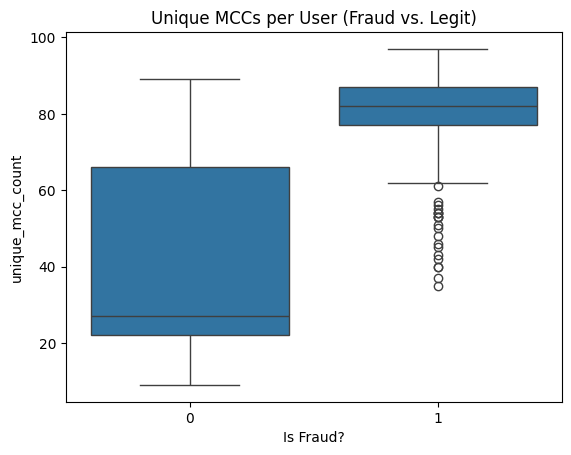

0          91
1          91
2          91
3          91
4          91
           ..
7374874    83
7374875    83
7374876    83
7374877    83
7374878    83
Name: unique_mcc_count, Length: 7374879, dtype: int64

In [66]:
# Unique MCCs per User (Potential Card Testing)
user_mcc_counts = df.groupby("User")["MCC"].nunique().reset_index()
user_mcc_counts.columns = ["User", "unique_mcc_count"]

# Merge with fraud labels
user_fraud_status = df.groupby("User")["Is Fraud?"].max().reset_index()
final_result = user_mcc_counts.merge(user_fraud_status, on="User")

# Compare fraud vs. non-fraud users
sns.boxplot(x="Is Fraud?", y="unique_mcc_count", data=final_result)
plt.title("Unique MCCs per User (Fraud vs. Legit)")
plt.show()

# feature engineering
df = df.merge(user_mcc_counts, on="User", how="left")
df["unique_mcc_count"]

the plot shows that fraudsters switch MCCs more often

In [67]:
df = df.sort_values(["User", "timestamp"])
# Calculate MCC changes, time, and amount differences
df["next_mcc"] = df.groupby("User")["MCC"].shift(-1)
df["next_mcc"] = df.groupby("User")["MCC"].shift(-1)
df["mcc_changed"] = (df["MCC"] != df["next_mcc"]).astype(int)
df["time_diff"] = df.groupby("User")["timestamp"].diff(-1).abs()
df["amt_diff"] = df.groupby("User")["Amount"].diff(-1).abs()

# Filter rapid changes (e.g., <1 hour)
df["Rapid_mcc_changed"] = (
    (df["mcc_changed"] == 1) & (df["time_diff"] <= pd.Timedelta(hours=1))
).astype(int)
# Compare fraud vs. non-fraud behavior
print("Overall MCC switching rate:")
print(df.groupby("mcc_changed")["Is Fraud?"].mean())

print("\nRapid MCC switching rate (<1 hour):")
print(df.groupby("Rapid_mcc_changed")["Is Fraud?"].mean())

Overall MCC switching rate:
mcc_changed
0    0.000494
1    0.001457
Name: Is Fraud?, dtype: float64

Rapid MCC switching rate (<1 hour):
Rapid_mcc_changed
0    0.000928
1    0.003242
Name: Is Fraud?, dtype: float64


Fraud rate for MCC change transactions is higher, especially when the switch happens within 1 hour. Fraudsters tend to switch MCCs quickly.

## Geographically related merchant identifier


In [68]:
# check for high risk merchant names
df["Merchant Name"] = df["Merchant Name"].astype(str)
fraud_stats_by_merchant = (
    df.groupby("Merchant Name")["Is Fraud?"]
    .agg(["count", "mean"])
    .sort_values(by="mean", ascending=False)
)

# Rename columns for clarity
fraud_stats_by_merchant.columns = ["transaction_count", "fraud_rate"]

# Filter out merchants with too few transactions
high_risk_merchants = fraud_stats_by_merchant[
    (fraud_stats_by_merchant["transaction_count"] >= 20)  # Minimum threshold
    & (fraud_stats_by_merchant["fraud_rate"] > 0.1)
]

# feature engineering:
df["High_risk_merchant"] = df["Merchant Name"].apply(
    lambda x: 1 if x in high_risk_merchants.index else 0
)

In [69]:
df["Zip"].info()

<class 'pandas.core.series.Series'>
Index: 7374879 entries, 7615 to 7374878
Series name: Zip
Non-Null Count    Dtype 
--------------    ----- 
7374879 non-null  object
dtypes: object(1)
memory usage: 112.5+ MB


In [70]:
# Check if ZIP maps to multiple cities/states
zip_uniqueness = (
    df.groupby("Zip")[["Merchant City", "Merchant State"]].nunique().reset_index()
)
conflict_zips = zip_uniqueness[
    (zip_uniqueness["Merchant City"] > 1) | (zip_uniqueness["Merchant State"] > 1)
]
print(conflict_zips)

           Zip  Merchant City  Merchant State
21897  Unknown            149             128


\The analysis confirms that each (Merchant City, Merchant State) pair maps to a unique ZIP code with no conflicts.

In [71]:
# Identify US ZIPs (5-digit or 4-digit with missing leading zero)
df["is_us_zip"] = df["Zip"].str.match(r"^\d{4,5}$")  # Matches 4 or 5 digits

# Pad 4-digit ZIPs with leading zero (e.g., "1234" → "01234")
df.loc[df["is_us_zip"] & df["Zip"].str.len() == 4, "Zip"] = "0" + df["Zip"]

In [72]:
# modifying Zipcode data type in order to compare with Zip
df["Zipcode"] = df["Zipcode"].astype(str)

In [73]:
# separating us transactions
us_trns = df[df["is_us_zip"]]

In [74]:
# exact match flag
us_trns["is_same_zip"] = (us_trns["Zip"] == us_trns["Zipcode"]).astype(str)
# Compare Fraud Rate Between Transactions Occurring in the User's Zip Code vs. a Different Zip Code
us_trns.groupby("is_same_zip")["Is Fraud?"].agg(["mean", "count", "sum"])

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\1868118995.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  us_trns['is_same_zip']=(us_trns['Zip']==us_trns['Zipcode']).astype(str)


,mean,count,sum
is_same_zip,,,
False,0.000530,2728735,1445
True,0.000016,3733122,60


In [75]:
# feature engineering:
df["zip_mismatch_flag"] = (df["Zip"] != df["Zipcode"]) & df["is_us_zip"]
df["zip_mismatch_flag"] = df["zip_mismatch_flag"].astype(int)

The analysis revealed that transactions occurring in a different ZIP code than the user's registered ZIP code within the U.S. have a higher fraud rate compared to those happening in the same ZIP code. This suggests that ZIP code mismatch can be a valuable feature for fraud detection models, as it may indicate unusual or suspicious transaction behavior.

## Feature: expiry date

In [79]:
# Convert Expires to datetime format
df["Expires"] = pd.to_datetime(df["Expires"], format="%Y-%m-%d")
df["months_to_expiry"] = ((df["Expires"] - df["timestamp"]).dt.days) / 30
df["months_to_expiry"]

df.groupby(pd.cut(df["months_to_expiry"], [-np.inf, 0, 6, 12, 24, np.inf]))[
    "Is Fraud?"
].agg(["mean", "sum", "count"])

C:\Users\Milad\AppData\Local\Temp\ipykernel_20328\1420975629.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['months_to_expiry'], [-np.inf, 0, 6, 12, 24, np.inf]))['Is Fraud?'].agg(['mean','sum','count'])


,mean,sum,count
months_to_expiry,,,
"(-inf, 0.0]",0.001266,24,18959
"(0.0, 6.0]",0.001490,158,106057
"(6.0, 12.0]",0.001610,201,124846
"(12.0, 24.0]",0.001243,391,314672
"(24.0, inf]",0.001241,8454,6810345


The analysis indicates that fraudulent transactions are more frequent on cards nearing expiration. Cards with less than 1 year to expiry show a notably higher fraud rate compared to those with longer validity.

Transactions where the card was already expired at the time of use should be removed to ensure data quality and accuracy of the fraud analysis.

In [80]:
df.to_csv("FE_&_EDA.csv", index=False)

In [1]:
df

NameError: name 'df' is not defined